In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2e3148',
    'axes.labelcolor'  : '#c9d1d9',
    'text.color'       : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : '#e6edf3',
})

PALETTE = ["#5caf91", "#448d72", "#40866c", "#34705a", "#2d755b", "#1c4838"]
PROC_DIR = '../data/processed'
VIZ_DIR  = '../visuals'
os.makedirs(VIZ_DIR, exist_ok=True)


accounts        = pd.read_csv(f'{PROC_DIR}/accounts_clean.csv',       parse_dates=['signup_date'])
subscriptions   = pd.read_csv(f'{PROC_DIR}/subscriptions_clean.csv',  parse_dates=['start_date','end_date'])
feature_usage   = pd.read_csv(f'{PROC_DIR}/feature_usage_clean.csv',  parse_dates=['usage_date'])
support_tickets = pd.read_csv(f'{PROC_DIR}/support_tickets_clean.csv',parse_dates=['submitted_at','closed_at'])
churn_events    = pd.read_csv(f'{PROC_DIR}/churn_events_clean.csv',   parse_dates=['churn_date'])

paid_subs = subscriptions[
    (subscriptions['is_trial'] == False) &
    (subscriptions['mrr_amount'] > 0)
].copy()

print('All datasets loaded.')

All datasets loaded.


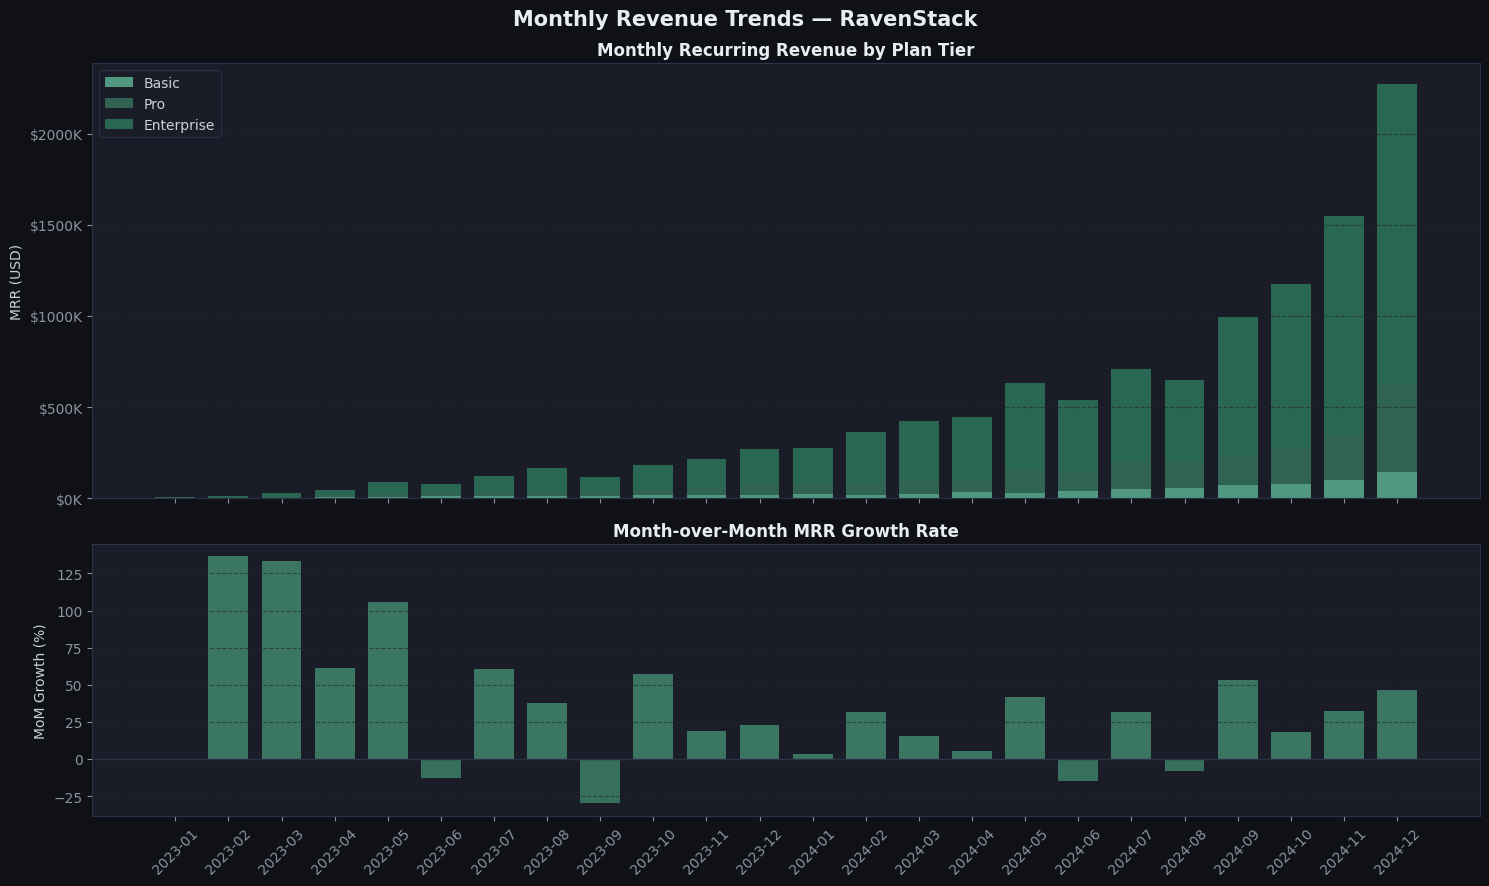

Saved: 15_mrr_trend.png


In [32]:
paid_subs['month'] = paid_subs['start_date'].dt.to_period('M')

mrr_monthly = (
    paid_subs
    .groupby(['month', 'plan_tier'])['mrr_amount']
    .sum()
    .unstack('plan_tier')
    .fillna(0)
)

plan_order = [p for p in ['Basic', 'Pro', 'Enterprise'] if p in mrr_monthly.columns]
mrr_monthly = mrr_monthly[plan_order]
mrr_monthly['total_mrr'] = mrr_monthly.sum(axis=1)
mrr_monthly['mom_growth'] = mrr_monthly['total_mrr'].pct_change() * 100

month_str = mrr_monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                          gridspec_kw={'height_ratios': [1.6, 1]})
fig.suptitle('Monthly Revenue Trends — RavenStack', fontsize=15,
             fontweight='bold', color='#e6edf3')

bottom = np.zeros(len(mrr_monthly))
plan_colors = {'Basic': PALETTE[0], 'Pro': PALETTE[3], 'Enterprise': PALETTE[4]}
for plan in plan_order:
    axes[0].bar(month_str, mrr_monthly[plan], bottom=bottom,
                 label=plan, color=plan_colors.get(plan, PALETTE[0]),
                 alpha=0.85, width=0.75)
    bottom += mrr_monthly[plan].values

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_ylabel('MRR (USD)')
axes[0].set_title('Monthly Recurring Revenue by Plan Tier')
axes[0].legend(loc='upper left', facecolor='#1a1d27',
                edgecolor='#2e3148', labelcolor='#c9d1d9')
axes[0].grid(axis='y')

growth = mrr_monthly['mom_growth'].fillna(0)
bar_colors = [PALETTE[1] if g >= 0 else PALETTE[2] for g in growth]
axes[1].bar(month_str, growth, color=bar_colors, alpha=0.80, width=0.75)
axes[1].axhline(0, color='#2e3148', linewidth=1)
axes[1].set_ylabel('MoM Growth (%)')
axes[1].set_title('Month-over-Month MRR Growth Rate')
axes[1].grid(axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/15_mrr_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 15_mrr_trend.png')

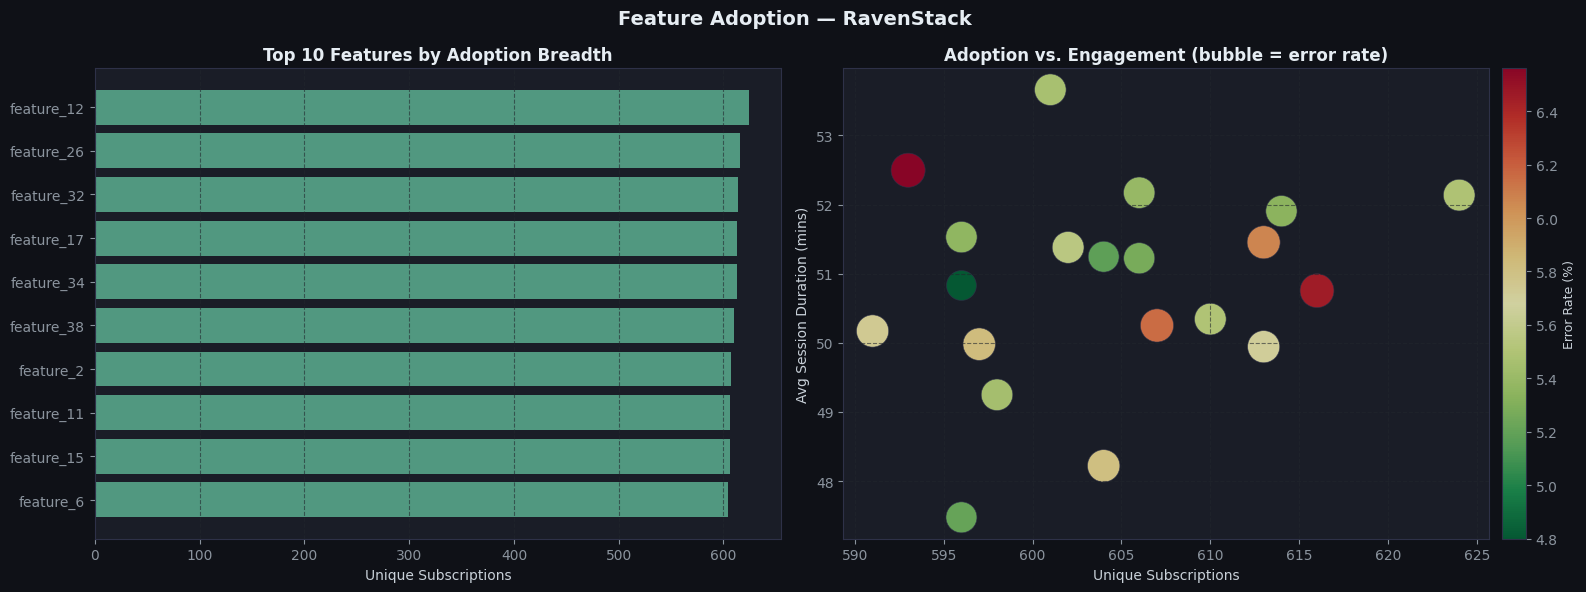

Saved: 16_feature_adoption.png


In [ ]:
feature_breadth = (
    feature_usage
    .groupby('feature_name')
    .agg(
        unique_subs    = ('subscription_id', 'nunique'),
        total_events   = ('usage_id', 'count'),
        total_count    = ('usage_count', 'sum'),
        avg_duration   = ('usage_duration_secs', 'mean'),
        total_errors   = ('error_count', 'sum'),
        is_beta        = ('is_beta_feature', 'max')
    )
    .sort_values('unique_subs', ascending=False)
)

feature_breadth['error_rate'] = (
    feature_breadth['total_errors'] /
    feature_breadth['total_count'].clip(lower=1) * 100
).round(2)

top10 = feature_breadth.head(10)
bot10 = feature_breadth.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Adoption — RavenStack', fontsize=14, fontweight='bold', color='#e6edf3')

axes[0].barh(top10.index[::-1], top10['unique_subs'][::-1],
              color=PALETTE[0], alpha=0.85)
axes[0].set_xlabel('Unique Subscriptions')
axes[0].set_title('Top 10 Features by Adoption Breadth')
axes[0].grid(axis='x')

top20 = feature_breadth.head(20)
bubble_size = (top20['error_rate'] + 1) * 80   
scatter = axes[1].scatter(
    top20['unique_subs'],
    top20['avg_duration'] / 60,
    s=bubble_size,
    c=top20['error_rate'],
    cmap='RdYlGn_r',
    alpha=0.80,
    edgecolors='#2e3148',
    linewidth=0.5
)
cbar = fig.colorbar(scatter, ax=axes[1], fraction=0.04, pad=0.02)
cbar.set_label('Error Rate (%)', color='#c9d1d9', fontsize=9)
axes[1].set_xlabel('Unique Subscriptions')
axes[1].set_ylabel('Avg Session Duration (mins)')
axes[1].set_title('Adoption vs. Engagement (bubble = error rate)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/16_feature_adoption.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 16_feature_adoption.png')

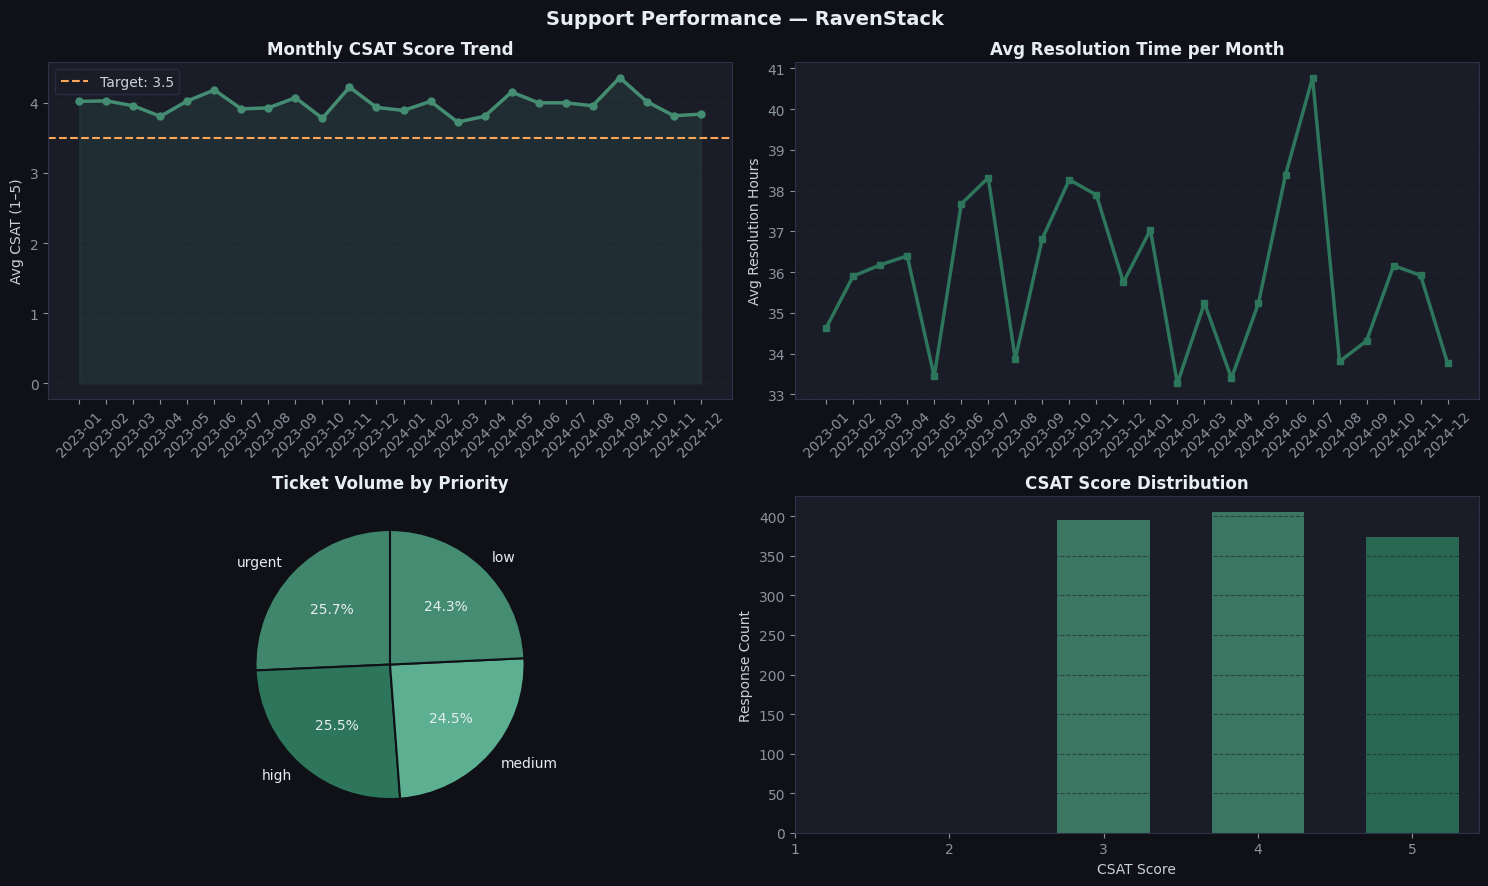

Saved: 17_support_dashboard.png


In [34]:
support_tickets['month'] = support_tickets['submitted_at'].dt.to_period('M')

csat_trend = (
    support_tickets
    .groupby('month')
    .agg(
        avg_csat    = ('satisfaction_score', 'mean'),
        tickets     = ('ticket_id', 'count'),
        escalations = ('escalation_flag', 'sum'),
        avg_res_hrs = ('resolution_time_hours', 'mean')
    )
    .reset_index()
)
month_str_s = csat_trend['month'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Support Performance — RavenStack', fontsize=14,
             fontweight='bold', color='#e6edf3')

axes[0,0].plot(month_str_s, csat_trend['avg_csat'], color=PALETTE[1],
                linewidth=2.5, marker='o', markersize=5)
axes[0,0].fill_between(month_str_s, csat_trend['avg_csat'],
                         alpha=0.15, color=PALETTE[1])
axes[0,0].axhline(3.5, color='#ffa657', linestyle='--', linewidth=1.5, label='Target: 3.5')
axes[0,0].set_ylabel('Avg CSAT (1–5)')
axes[0,0].set_title('Monthly CSAT Score Trend')
axes[0,0].legend(facecolor='#1a1d27', edgecolor='#2e3148', labelcolor='#c9d1d9')
axes[0,0].grid(axis='y')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].plot(month_str_s, csat_trend['avg_res_hrs'], color=PALETTE[4],
                linewidth=2.5, marker='s', markersize=5)
axes[0,1].set_ylabel('Avg Resolution Hours')
axes[0,1].set_title('Avg Resolution Time per Month')
axes[0,1].grid(axis='y')
axes[0,1].tick_params(axis='x', rotation=45)

priority_counts = support_tickets['priority'].value_counts()
pie_colors = [PALETTE[2], PALETTE[4], PALETTE[0], PALETTE[1]]
axes[1,0].pie(priority_counts, labels=priority_counts.index,
               autopct='%1.1f%%', colors=pie_colors,
               textprops={'color': '#e6edf3', 'fontsize': 10},
               wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5},
               startangle=90)
axes[1,0].set_title('Ticket Volume by Priority')
axes[1,0].set_facecolor('#1a1d27')

csat_dist = support_tickets['satisfaction_score'].dropna().value_counts().sort_index()
bar_csat_colors = [PALETTE[2], PALETTE[2], PALETTE[4], PALETTE[1], PALETTE[1]]
axes[1,1].bar(csat_dist.index.astype(int), csat_dist.values,
               color=bar_csat_colors, alpha=0.85, width=0.6)
axes[1,1].set_xlabel('CSAT Score')
axes[1,1].set_ylabel('Response Count')
axes[1,1].set_title('CSAT Score Distribution')
axes[1,1].set_xticks([1,2,3,4,5])
axes[1,1].grid(axis='y')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/17_support_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 17_support_dashboard.png')

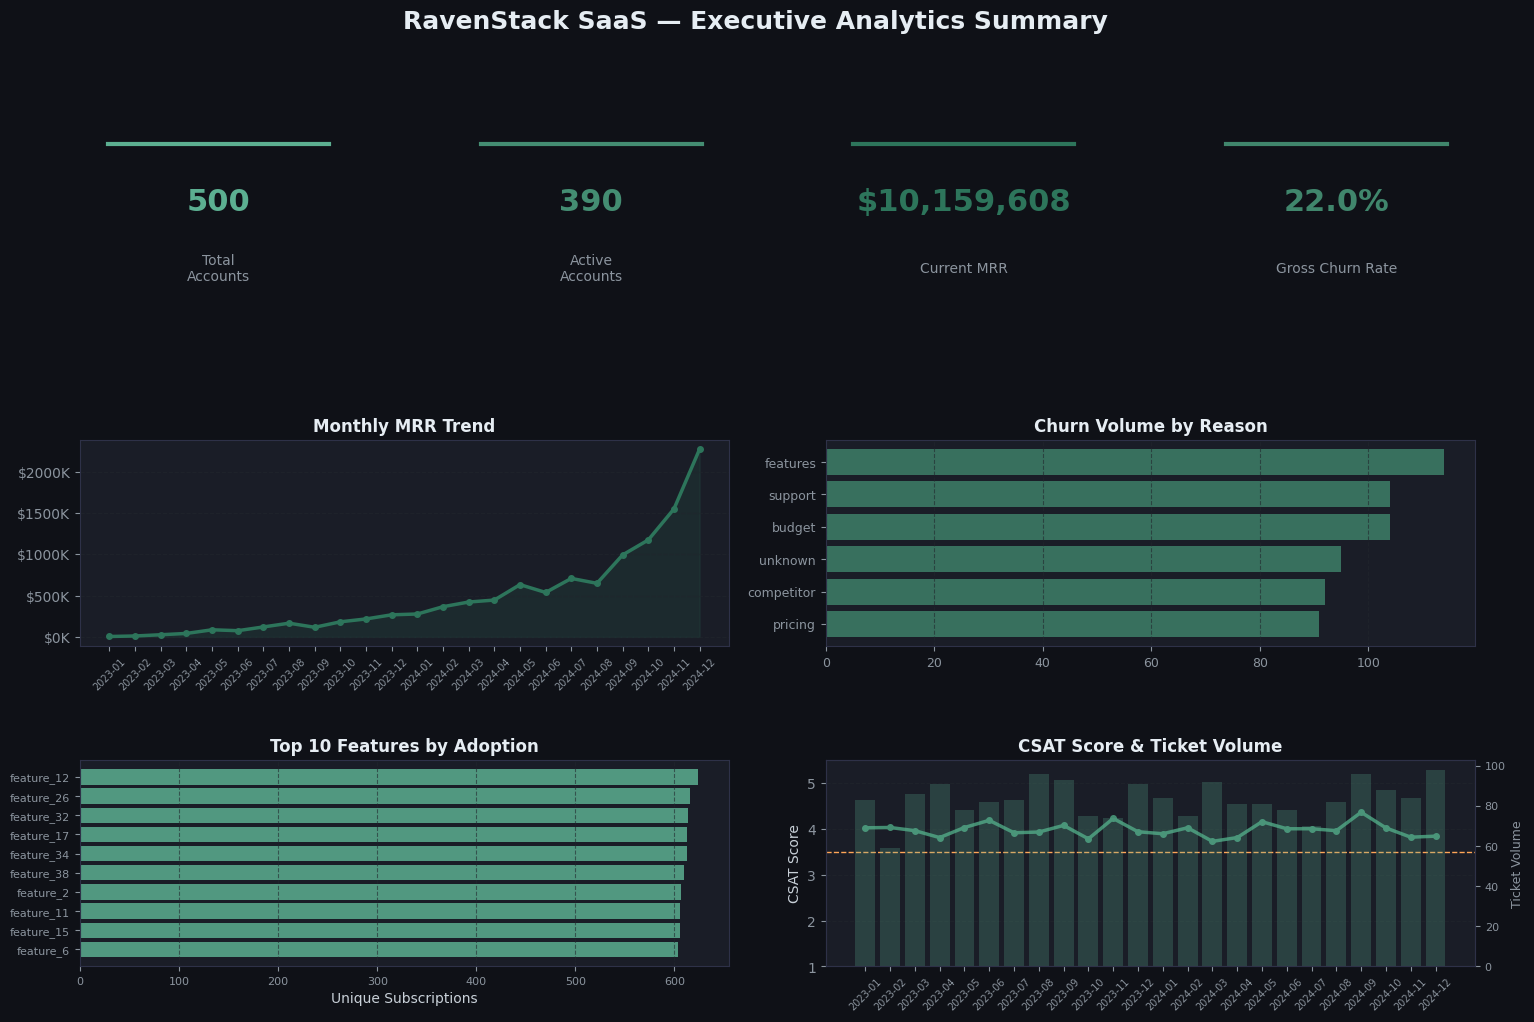

Saved: 00_executive_dashboard.png


In [35]:
total_accounts   = len(accounts)
churned_accounts = accounts['churn_flag'].sum()
active_accounts  = total_accounts - churned_accounts
churn_rate       = churned_accounts / total_accounts * 100
total_mrr        = paid_subs['mrr_amount'].sum()
current_mrr      = paid_subs[paid_subs['churn_flag'] == False]['mrr_amount'].sum()
current_arr      = current_mrr * 12
avg_csat         = support_tickets['satisfaction_score'].mean()
top_feature      = feature_breadth['unique_subs'].idxmax()
top_churn_reason = churn_events['reason_code'].value_counts().idxmax()

fig = plt.figure(figsize=(18, 11), facecolor='#0f1117')
fig.suptitle('RavenStack SaaS — Executive Analytics Summary',
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.35)

kpi_items = [
    ('Total\nAccounts',    f'{total_accounts:,}',   PALETTE[0]),
    ('Active\nAccounts',   f'{active_accounts:,}',  PALETTE[1]),
    ('Current MRR',        f'${current_mrr:,.0f}',  PALETTE[4]),
    ('Gross Churn Rate',   f'{churn_rate:.1f}%',    PALETTE[2]),
]
for col, (label, value, color) in enumerate(kpi_items):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor('#161b22')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.axhline(0.88, xmin=0.1, xmax=0.9, color=color, linewidth=3)
    ax.text(0.5, 0.60, value,  ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=10, color='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2e3148')

ax_mrr = fig.add_subplot(gs[1, 0:2])
mrr_total_monthly = mrr_monthly['total_mrr']
ax_mrr.plot(mrr_total_monthly.index.astype(str), mrr_total_monthly.values,
             color=PALETTE[4], linewidth=2.5, marker='o', markersize=4)
ax_mrr.fill_between(mrr_total_monthly.index.astype(str),
                     mrr_total_monthly.values, alpha=0.15, color=PALETTE[4])
ax_mrr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax_mrr.set_title('Monthly MRR Trend')
ax_mrr.grid(axis='y')
ax_mrr.tick_params(axis='x', rotation=45, labelsize=7)

ax_churn = fig.add_subplot(gs[1, 2:4])
reason_vc = churn_events['reason_code'].value_counts()
ax_churn.barh(reason_vc.index[::-1], reason_vc.values[::-1],
               color=PALETTE[2], alpha=0.80)
ax_churn.set_title('Churn Volume by Reason')
ax_churn.grid(axis='x')
ax_churn.tick_params(labelsize=9)

ax_feat = fig.add_subplot(gs[2, 0:2])
top10_feat = feature_breadth['unique_subs'].head(10)
ax_feat.barh(top10_feat.index[::-1], top10_feat.values[::-1],
              color=PALETTE[0], alpha=0.85)
ax_feat.set_title('Top 10 Features by Adoption')
ax_feat.set_xlabel('Unique Subscriptions')
ax_feat.grid(axis='x')
ax_feat.tick_params(labelsize=8)

ax_csat = fig.add_subplot(gs[2, 2:4])
ax_csat.plot(month_str_s, csat_trend['avg_csat'], color=PALETTE[1],
              linewidth=2.5, marker='o', markersize=4, label='Avg CSAT')
ax_twin = ax_csat.twinx()
ax_twin.bar(month_str_s, csat_trend['tickets'],
             color=PALETTE[0], alpha=0.25, label='Tickets')
ax_twin.set_ylabel('Ticket Volume', color='#8b949e', fontsize=9)
ax_twin.tick_params(axis='y', colors='#8b949e', labelsize=8)
ax_csat.set_ylabel('CSAT Score')
ax_csat.set_title('CSAT Score & Ticket Volume')
ax_csat.axhline(3.5, color='#ffa657', linestyle='--', linewidth=1)
ax_csat.grid(axis='y')
ax_csat.tick_params(axis='x', rotation=45, labelsize=7)
ax_csat.set_ylim(1, 5.5)

plt.savefig(f'{VIZ_DIR}/00_executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 00_executive_dashboard.png')

In [36]:
ref_churn = (
    accounts.groupby('referral_source')
    .agg(total=('account_id','count'), churned=('churn_flag','sum'))
    .assign(rate=lambda x: x['churned']/x['total']*100)
)
best_channel  = ref_churn['rate'].idxmin()
best_rate     = ref_churn.loc[best_channel, 'rate']
worst_channel = ref_churn['rate'].idxmax()
worst_rate    = ref_churn.loc[worst_channel, 'rate']

plan_churn = (
    accounts.groupby('plan_tier')
    .agg(total=('account_id','count'), churned=('churn_flag','sum'))
    .assign(rate=lambda x: x['churned']/x['total']*100)
)
highest_churn_plan = plan_churn['rate'].idxmax()
lowest_churn_plan  = plan_churn['rate'].idxmin()

tpa = (
    support_tickets.groupby('account_id')['ticket_id']
    .count().rename('tix').reset_index()
)
sig = accounts.merge(tpa, on='account_id', how='left')
sig['tix'] = sig['tix'].fillna(0)
avg_tix_churned  = sig[sig['churn_flag']==True]['tix'].mean()
avg_tix_retained = sig[sig['churn_flag']==False]['tix'].mean()

high_error_feat = feature_breadth[feature_breadth['total_count'] > 100]['error_rate'].idxmax()
high_error_rate = feature_breadth.loc[high_error_feat, 'error_rate']

top_reason = churn_events['reason_code'].value_counts().idxmax()
top_reason_pct = churn_events['reason_code'].value_counts(normalize=True).max() * 100

print('=' * 65)
print('  KEY FINDINGS & DATA-DRIVEN RECOMMENDATIONS')
print('=' * 65)

findings = [
    (
        'FINDING 1 — Pricing is the #1 churn driver',
        f'  {top_reason!r} accounts for {top_reason_pct:.1f}% of all churn events.\n'
        f'  RECOMMENDATION: Introduce a mid-tier pricing option between Basic and Pro\n'
        f'  to reduce price-sensitivity churn. Consider annual discount incentives.'
    ),
    (
        f'FINDING 2 — {highest_churn_plan} plan has highest churn rate',
        f'  Churn rate: {plan_churn.loc[highest_churn_plan, "rate"]:.1f}% vs\n'
        f'  {lowest_churn_plan}: {plan_churn.loc[lowest_churn_plan, "rate"]:.1f}%.\n'
        f'  RECOMMENDATION: Add guided onboarding for {highest_churn_plan} users in\n'
        f'  the first 30 days (critical churn window).'
    ),
    (
        f'FINDING 3 — {best_channel.title()} channel has the best retention',
        f'  {best_channel!r} churn rate: {best_rate:.1f}% vs {worst_channel!r}: {worst_rate:.1f}%.\n'
        f'  RECOMMENDATION: Increase acquisition budget for {best_channel} channel.\n'
        f'  Review quality of leads from {worst_channel} source.'
    ),
    (
        'FINDING 4 — High support load precedes churn',
        f'  Churned accounts raised {avg_tix_churned:.1f} tickets on avg vs\n'
        f'  {avg_tix_retained:.1f} for retained accounts.\n'
        f'  RECOMMENDATION: Flag accounts with >3 tickets in 30 days for\n'
        f'  proactive customer success outreach.'
    ),
    (
        f'FINDING 5 — {high_error_feat} has elevated error rate ({high_error_rate:.1f}%)',
        f'  Error-prone features damage product experience and drive support volume.\n'
        f'  RECOMMENDATION: Prioritise stability fixes for {high_error_feat}\n'
        f'  in the next sprint cycle.'
    ),
]

for i, (title, detail) in enumerate(findings, 1):
    print(f'\n  ► {title}')
    print(detail)

  KEY FINDINGS & DATA-DRIVEN RECOMMENDATIONS

  ► FINDING 1 — Pricing is the #1 churn driver
  'features' accounts for 19.0% of all churn events.
  RECOMMENDATION: Introduce a mid-tier pricing option between Basic and Pro
  to reduce price-sensitivity churn. Consider annual discount incentives.

  ► FINDING 2 — Enterprise plan has highest churn rate
  Churn rate: 22.1% vs
  Pro: 21.9%.
  RECOMMENDATION: Add guided onboarding for Enterprise users in
  the first 30 days (critical churn window).

  ► FINDING 3 — Partner channel has the best retention
  'partner' churn rate: 14.6% vs 'event': 30.2%.
  RECOMMENDATION: Increase acquisition budget for partner channel.
  Review quality of leads from event source.

  ► FINDING 4 — High support load precedes churn
  Churned accounts raised 3.9 tickets on avg vs
  4.0 for retained accounts.
  RECOMMENDATION: Flag accounts with >3 tickets in 30 days for
  proactive customer success outreach.

  ► FINDING 5 — feature_4 has elevated error rate (6.6%

In [37]:
metrics = {
    'Total Accounts'              : total_accounts,
    'Active Accounts'             : int(active_accounts),
    'Churned Accounts'            : int(churned_accounts),
    'Gross Churn Rate (%)'        : round(churn_rate, 2),
    'Current MRR (USD)'           : round(current_mrr, 2),
    'Current ARR (USD)'           : round(current_arr, 2),
    'Total Lifetime MRR (USD)'    : round(total_mrr, 2),
    'Avg CSAT Score'              : round(avg_csat, 2),
    'Total Support Tickets'       : len(support_tickets),
    'Avg Resolution Time (hrs)'   : round(support_tickets['resolution_time_hours'].mean(), 2),
    'Reactivations'               : int(churn_events['is_reactivation'].sum()),
    'Top Churn Reason'            : top_reason,
    'Best Retention Channel'      : best_channel,
    'Most Adopted Feature'        : top_feature,
}

metrics_df = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
metrics_df.index.name = 'Metric'
metrics_df.to_csv(f'{PROC_DIR}/final_metrics_summary.csv')

print('✓ Saved: final_metrics_summary.csv')
print('\nFinal Metrics Summary:')
display(metrics_df)

✓ Saved: final_metrics_summary.csv

Final Metrics Summary:


,Value
Metric,
Total Accounts,500
Active Accounts,390
Churned Accounts,110
Gross Churn Rate (%),22.0
Current MRR (USD),10159608
Current ARR (USD),121915296
Total Lifetime MRR (USD),11338747
Avg CSAT Score,3.98
Total Support Tickets,2000
